# EVALUACIÓN FINAL MÓDULO 3

In [1]:
# importación de las librerías necesarias

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

***
- **ÍNDICE:**
- **FASE 1. EXPLORACIÓN Y LIMPIEZA**
- 1. RECOPILACIÓN, EXPLORACIÓN Y TRANSFORMACIÓN DE DATOS
- 1.1 Búsqueda de duplicados
- 1.2 Comprobación de nulos
- 1.3 Otras comprobaciones numéricas
- 1.4 Revisión de columnas categóricas
- 1.5 Tratamiento de nulos
- 2. UNIÓN DE DATASETS
- 2.1 Exploración, limpieza y transformaición

- **FASE 2. ANÁLISIS ESTADÍSTICO**
- 1 VARIABLES NUMÉRICAS
- 2 VARIABLES CATEGÓRICAS

- **FASE 3. VISUALIZACIÓN**

- **FASE 4. EVALUACIÓN DE DIFERENCIAS EN RESERVAS DE VUELOS POR NIVEL EDUCATIVO**
***

Estructuración de los puntos a tratar:
- Actividad: señalo el trabajo a realizar
- Resultado: redacto lo que he hecho
- Decisión: en los puntos que hay que tomar alguna decisión (eliminación, imputación, etc), lo anoto detrás de esta palabra


# FASE 1. EXPLORACIÓN Y LIMPIEZA


# 1. RECOPILACIÓN, EXPLORACIÓN Y TRANSFORMACIÓN DE DATOS

Actividad: Vamos a dar diferentes instrucciones a Python para poder explorar los datos de los dos datasets que tenemos

In [2]:
# Lectura de ficheres csv: no quito índice de pandas por si en algún momento viene bien tenerlo
# Lectura del primer fichero: df_custflight
df_custflight = pd.read_csv('./files/Customer Flight Activity.csv')
df_custflight.head()  # visualización de las 5 primeras filas

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [3]:
# Lectura del segundo fichero: df_custloyalty
df_custloyalty = pd.read_csv('./files/Customer Loyalty History.csv')
df_custloyalty.head() # visualización de las 5 primeras filas

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [4]:
# Visualización de datos centrales fichero df_custflight: sample nos los muestra de forma aleatoria
df_custflight.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
259779,434751,2018,4,0,0,0,0,0.0,0,0
132472,852392,2017,8,0,0,0,0,0.0,0,0
155205,265677,2017,10,8,4,12,3636,363.0,0,0
207122,330694,2018,1,0,0,0,0,0.0,0,0
285393,896685,2018,5,0,0,0,0,0.0,0,0


In [5]:
#Visualización de datos centrales segundo fichero: df_custloyalty
df_custloyalty.sample(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
11500,846194,Canada,Ontario,Kingston,M9K 2P4,Male,College,NaN,Single,Star,2660.01,Standard,2013,3,NaN,NaN
7597,539854,Canada,Ontario,Toronto,P1W 1K4,Female,Bachelor,53487.0,Married,Nova,7347.41,Standard,2016,9,2017.0,12.0
318,766927,Canada,Ontario,Toronto,P1J 8T7,Male,Bachelor,71936.0,Divorced,Star,4457.94,Standard,2016,4,NaN,NaN
15770,437158,Canada,Ontario,Toronto,M1R 4K3,Male,Bachelor,60388.0,Married,Star,11318.09,Standard,2015,4,NaN,NaN
15194,328668,Canada,Ontario,Toronto,M2P 4F6,Female,Bachelor,100976.0,Married,Star,8649.70,Standard,2013,10,NaN,NaN


In [6]:
# Visualización datos finales fichero df_custflight
df_custflight.tail()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405619,999902,2018,12,0,0,0,0,0.0,0,0
405620,999911,2018,12,0,0,0,0,0.0,0,0
405621,999940,2018,12,3,0,3,1233,123.0,0,0
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


In [7]:
# Visualización datos finales segundo fichero df_custflight
df_custloyalty.tail()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


In [50]:
# Obtención de información fichero custflight
df_custflight.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [51]:
# Obtención de información fichero custloyalty
df_custloyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [52]:
# Visualización columnas fichero df_custflight
df_custflight.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='str')

In [53]:
# Visualización columnas fichero df_custloyalty
df_custloyalty.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='str')

In [54]:
# Obtención información tamaño fichero
df_custflight.shape

(405624, 10)

In [55]:
# Obtención de información tamaño fichero
df_custloyalty.shape

(16737, 16)

## 1.1. Búsqueda de duplicados

Actividad: búsqueda de duplicado en ficheros

In [8]:
df_custflight.duplicated().sum()

np.int64(1864)

In [9]:
df_custloyalty.duplicated().sum()

np.int64(0)

Resultado:
- Hay filas duplicadas en df_custflight
- No hay filas duplicadas en df_custloyalty

Decisión: Vamos a borrar las filas de df_custflight, dejando la primera de ellas porque las demás son exactamente iguales

In [4]:
#Eliminación de filas duplicadas porque son exactamente iguales
df_custflight.drop_duplicates(keep='first', inplace=True) # hemos puesto keep='first' para que deje la primera fila y borre las demás que son exactamente iguales aunque no haaría falta porque por defecto lo hace ya así

In [5]:
#Comprobación de que se han eliminado
df_custflight.duplicated().sum()

np.int64(0)

## 1.2. Comprobación de nulos

Actividad: comprobación de existencia de nulos en ficheros

In [12]:
df_custflight.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [13]:
df_custloyalty.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [60]:
# Visualización en porcentaje de los nulos para una mejor comprensión
(df_custloyalty.isnull().sum() / df_custloyalty.shape[0] * 100).round(2) 

Loyalty Number        0.00
Country               0.00
Province              0.00
City                  0.00
Postal Code           0.00
Gender                0.00
Education             0.00
Salary               25.32
Marital Status        0.00
Loyalty Card          0.00
CLV                   0.00
Enrollment Type       0.00
Enrollment Year       0.00
Enrollment Month      0.00
Cancellation Year    87.65
Cancellation Month   87.65
dtype: float64

Resultado:
- No hay ningún nulo en df_flight
- En df_loyalty si tenemos nulos en 3 filas: Salary, Cancellation Year y Cancellation Month

## 1.3. Otras comprobaciones columnas numéricas

Actividad: Otras comprobaciones en columnas numéricas para identificar posibles inconsistencias

In [61]:
# Visualización principales estadísticas de columnas fichero df_custflight
df_custflight.describe()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,403760.00,403760.00,403760.00,403760.00,403760.00,403760.00,403760.00,403760.00,403760.00,403760.00
mean,549875.38,2017.50,6.50,4.13,1.04,5.17,1214.46,124.26,30.84,2.50
std,258961.51,0.50,3.45,5.23,2.08,6.53,1434.10,146.70,125.76,10.17
min,100018.00,2017.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,326699.00,2017.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,550598.00,2018.00,7.00,1.00,0.00,1.00,525.00,53.00,0.00,0.00
75%,772152.00,2018.00,10.00,8.00,1.00,10.00,2342.00,240.00,0.00,0.00
max,999986.00,2018.00,12.00,21.00,11.00,32.00,6293.00,676.50,876.00,71.00


In [62]:
# Visualización principales estadísticas de columnas fichero df_custloyalty
df_custloyalty.describe()

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,16737.00,12499.00,16737.00,16737.00,16737.00,2067.00,2067.00
mean,549735.88,79245.61,7988.90,2015.25,6.67,2016.50,6.96
std,258912.13,35008.30,6860.98,1.98,3.40,1.38,3.46
min,100018.00,-58486.00,1898.01,2012.00,1.00,2013.00,1.00
25%,326603.00,59246.50,3980.84,2014.00,4.00,2016.00,4.00
50%,550434.00,73455.00,5780.18,2015.00,7.00,2017.00,7.00
75%,772019.00,88517.50,8940.58,2017.00,10.00,2018.00,10.00
max,999986.00,407228.00,83325.38,2018.00,12.00,2018.00,12.00


Resultado: Salary aparece con signo negativo. Se trata de un error porque un salario no puede ser nunca negativo

Actividad: vamos a explorar Salary específicamente para ver de donde viene el problema

In [63]:
# Visualización salario máximo
df_custloyalty['Salary'].max() 

np.float64(407228.0)

In [64]:
# Visualización salario mínimo
df_custloyalty['Salary'].min()

np.float64(-58486.0)

In [65]:
# Suma de datos afectados
(df_custloyalty['Salary'] < 0).sum()

np.int64(20)

In [66]:
# Visualización datos afectados
df_custloyalty[df_custloyalty['Salary'] < 0]['Salary']

1082    -49830.00
1894    -12497.00
2471    -46683.00
3575    -45962.00
3932    -19325.00
4712    -43234.00
6560    -10605.00
6570    -17534.00
7373    -58486.00
8576    -31911.00
8767    -49001.00
10232   -34079.00
11635    -9081.00
12596   -46470.00
13564   -26322.00
14327   -47310.00
14355   -39503.00
15416   -19332.00
16431   -46303.00
16735   -57297.00
Name: Salary, dtype: float64

In [67]:
# Visualización tramo completo afectados
df_custloyalty[df_custloyalty['Salary'] < 0]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.00,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.00,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.00,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.00,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.00,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.00,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.00,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.00,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.00,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.00,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


Resultado:
- Tienen todos en común 2018 Promotion en la columna Enrollment Type y el año 2018 en la columna Enrollment Year
- Son todos Bachelor (columna Education) y un Hight School

Actividad: Vamos a ubicar e inspeccionar donde están los registros con salario negativo respecto al resto de variables del dataset

In [15]:
df_custloyalty[df_custloyalty['Salary'] < 0]['Enrollment Type'].value_counts()

Enrollment Type
2018 Promotion    20
Name: count, dtype: int64

In [30]:
df_custloyalty['Education'].value_counts()

Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

Actividad: Vamos a compararlos con otros salarios de Bachelor y otras titulaciones

In [69]:
df_custloyalty[df_custloyalty['Education'] == 'Bachelor']['Salary'].sample(10, random_state=42)

8135     56345.00
16394    74580.00
14577    58717.00
6786    103197.00
4882     77914.00
10432    86233.00
7655     64240.00
8042     77935.00
16214    73638.00
5508     80697.00
Name: Salary, dtype: float64

In [36]:
df_custloyalty[['Education', 'Salary']].sample(20)

,Education,Salary
2733,Bachelor,93261.0
2104,Bachelor,72919.0
6258,High School or Below,66250.0
5748,College,NaN
6072,Bachelor,81290.0
16681,College,NaN
3404,College,NaN
10283,College,NaN
1115,College,NaN
10723,Bachelor,54633.0


In [70]:
df_custloyalty[(df_custloyalty['Education'] == 'Bachelor') & (df_custloyalty['Salary'] > 0)]['Salary'].min()

np.float64(15609.0)

In [16]:
df_custloyalty['Enrollment Type'].unique()

<ArrowStringArray>
['Standard', '2018 Promotion']
Length: 2, dtype: str

In [18]:
df_custloyalty[['Enrollment Type']].value_counts()

Enrollment Type
Standard           15766
2018 Promotion       971
Name: count, dtype: int64

Resultado: 
- Son sólo 20 de 971 usuarios, todos de Promotion 2018. Y además, dentro del total de Enrollment Type representa una cantidad más pequeña aún: 20 de 16737.
- Después de comparar las cantidades absolutas con otras de la misma y de las otras titulaciones, son cantidades coherentes.

Decisión: Vamos a cambiar el signo negativo a positivo por las siguientes razones:
- Posiblemente se trate de un error de entrada de datos: alguién tecleo el signo negativo. Los valores son creíbles, sólo el signo está mal.
- Considerarlos nulos sería desperdiciar información válida.
- Imputarlos sería inventar un dato cuando ya tenemos uno coherente.

In [6]:
# Conversión de negativos en positivos dejando los demás intactos
df_custloyalty['Salary'] = df_custloyalty['Salary'].abs()

In [7]:
# Comprobación de que hemos quitado los negativos
df_custloyalty[df_custloyalty['Salary'] < 0]['Enrollment Type'].value_counts()

Series([], Name: count, dtype: int64)

Actividad: Comprobación de decimales en Salary

In [8]:
# Comprobar si Salary tiene dos decimales
(df_custloyalty['Salary'] % 1 != 0).sum()

np.int64(4238)

Resultado: Hay muchos salarios con decimales. 
- Salary es float con lo que internamente los decimales están guardados y Pandas decide cuantos enseñar
- En pantalla queremos ver 2 para que todo quede igualado visualmente pero no queremos tocar nada interno

In [9]:
#Ponemos que en pantalla se vean dos decimales pero no afecta al código interno
pd.set_option('display.float_format', '{:.2f}'.format)

In [28]:
#Comprobación de que lo ha hecho
df_custloyalty.sample(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
13667,777714,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,90587.00,Married,Star,5408.91,Standard,2012,7,NaN,NaN
503,534794,Canada,Manitoba,Winnipeg,R2C 0M5,Male,Bachelor,66905.00,Married,Star,4708.20,Standard,2012,5,NaN,NaN
13382,447275,Canada,Alberta,Edmonton,T3G 6Y6,Male,Bachelor,51059.00,Single,Star,5116.62,Standard,2018,11,NaN,NaN
8068,718764,Canada,Ontario,Toronto,M2Z 4K1,Female,College,79345.51,Single,Nova,8276.44,Standard,2015,12,NaN,NaN
6601,481076,Canada,British Columbia,Vancouver,V6E 3Z3,Male,Bachelor,78976.00,Married,Nova,5363.41,Standard,2017,11,NaN,NaN


## 1.4. Revisión de columnas categóricas



Actividad: revisión de columnas categóricas

In [23]:
# Visualización de columnas categóricas con los tipos de datos que contienen
col_categoricas = df_custloyalty.select_dtypes(include='str').columns
# Bucle for para recorrer las columnas y poner el tipo de dato único
for col in col_categoricas:
    print(f"--- {col} ---")
    print(df_custloyalty[col].unique())
    print()

--- Country ---
<ArrowStringArray>
['Canada']
Length: 1, dtype: str

--- Province ---
<ArrowStringArray>
[             'Ontario',              'Alberta',     'British Columbia',
               'Quebec',                'Yukon',        'New Brunswick',
             'Manitoba',          'Nova Scotia',         'Saskatchewan',
         'Newfoundland', 'Prince Edward Island']
Length: 11, dtype: str

--- City ---
<ArrowStringArray>
[       'Toronto',       'Edmonton',      'Vancouver',           'Hull',
     'Whitehorse',        'Trenton',       'Montreal',   'Dawson Creek',
    'Quebec City',    'Fredericton',         'Ottawa',      'Tremblant',
        'Calgary',    'Thunder Bay',       'Whistler',    'Peace River',
       'Winnipeg',        'Sudbury', 'West Vancouver',        'Halifax',
         'London',         'Regina',        'Kelowna',     'St. John's',
       'Victoria',       'Kingston',          'Banff',        'Moncton',
  'Charlottetown']
Length: 29, dtype: str

--- Postal Code -

Resultado: No se aprecian mezclas de mayúsculas y minúsculas, espacios entre letras, ni erratas, por lo que no realizaremos transformación

## 1.5. Tratamiento de nulos

Actividad: Sabemos que los nulos están en Education, pero vamos a investigar si dentro de Education se concentran en algún grupo concreto

In [24]:
# Variable y bucle for que recorre las columnas para ver donde están los nulos
invest_nulos = df_custloyalty.select_dtypes(include='str').columns

for col in invest_nulos:
    print(f"--- {col} ---")
    print("Nulos en Salary:")
    print(df_custloyalty[df_custloyalty['Salary'].isna()][col].value_counts(normalize=True))
    print("Distribución general:")
    print(df_custloyalty[col].value_counts(normalize=True))
    print()

--- Country ---
Nulos en Salary:
Country
Canada   1.00
Name: proportion, dtype: float64
Distribución general:
Country
Canada   1.00
Name: proportion, dtype: float64

--- Province ---
Nulos en Salary:
Province
Ontario                0.33
British Columbia       0.27
Quebec                 0.19
Alberta                0.06
Manitoba               0.04
New Brunswick          0.03
Nova Scotia            0.03
Saskatchewan           0.03
Newfoundland           0.02
Yukon                  0.01
Prince Edward Island   0.00
Name: proportion, dtype: float64
Distribución general:
Province
Ontario                0.32
British Columbia       0.26
Quebec                 0.20
Alberta                0.06
Manitoba               0.04
New Brunswick          0.04
Nova Scotia            0.03
Saskatchewan           0.02
Newfoundland           0.02
Yukon                  0.01
Prince Edward Island   0.00
Name: proportion, dtype: float64

--- City ---
Nulos en Salary:
City
Toronto          0.20
Vancouver        0.1

Resultado: Todos los College son nulos. El 100 %

Actividad: Vamos a ver si están en algún año de inscripción concreto y lo comparamos con la distribución general de College

In [25]:
df_custloyalty[(df_custloyalty['Salary'].isna()) & (df_custloyalty['Education'] == 'College')]['Enrollment Year'].value_counts(normalize=True)

Enrollment Year
2018   0.18
2017   0.15
2016   0.15
2014   0.15
2013   0.14
2015   0.14
2012   0.10
Name: proportion, dtype: float64

In [25]:
df_custloyalty[df_custloyalty['Education'] == 'College']['Enrollment Year'].value_counts(normalize=True)

Enrollment Year
2018   0.18
2017   0.15
2016   0.15
2014   0.15
2013   0.14
2015   0.14
2012   0.10
Name: proportion, dtype: float64

Resultado: Las dos distribuciones son idénticas por lo que no importa cuando se inscribieron los College. Da igual la fecha, los Collegu siempre son nulos

Actividad: Vamos a verificar la cantidad y porcentaje que representan los College

In [27]:

df_custloyalty.groupby('Education')['Salary'].median().sort_values(ascending=True)

Education
High School or Below    61915.00
Bachelor                71960.00
Master                 105487.00
Doctor                 182143.50
College                      NaN
Name: Salary, dtype: float64

In [76]:
df_custloyalty['Education'].value_counts()

Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

In [42]:
df_custloyalty['Education'].value_counts(normalize=True).round(2) * 100

Education
Bachelor               63.00
College                25.00
High School or Below    5.00
Doctor                  4.00
Master                  3.00
Name: proportion, dtype: float64

Resultado: Los College son 4.238, lo que supone el 25 % dentro de los titulados. Todos sus salarios aparecen como nulos

Decisión: 
- Se trata de un porcentaje de nulos muy alto (25 %) por lo que vamos a imputar con un algoritmo, que es una técnica avanzada de imputación: Iterative Imputer
- Imputa cada columna que contiene nulos usando un modelo que tiene en cuenta todas las demás columnas y repite el proceso varias veces para refinar la estimación
- Iterative imputer es adecuado cuando tenemos como en este caso, un dataset grande y además queremos la máxima precisión

In [10]:

# Codificar Education como variable numérica (one-hot encoding)
df_temp = pd.get_dummies(df_custloyalty[['Salary', 'Education', 'CLV']], columns=['Education'])

# Aplicar el imputador iterativo
imputer = IterativeImputer(random_state=42)
df_imputado = imputer.fit_transform(df_temp)

# Recuperar el Salary ya imputado
df_custloyalty['Salary'] = df_imputado[:, df_temp.columns.get_loc('Salary')]

In [11]:
# Comprobación de desaparición de nulos
df_custloyalty.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                    0
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

# 2. UNION DE DATASETS

Actividad: Ver como se pueden unir los datasets
- Hemos visto que hay una columna común: Loyalty number
- ¿Cuántos valores únicos de esa columna hay en cada DataFrane?
- Ver si esos valores coinciden en uno y otro dataset

In [38]:
# ¿Cuántos valores únicos tiene en cada DataFrame?
print(df_custflight['Loyalty Number'].nunique())
print(df_custloyalty['Loyalty Number'].nunique())

16737
16737


In [47]:
# ¿Los valores coinciden entre ambos?
en_df_custflight = set(df_custflight['Loyalty Number'])
en_df_custtloyalty = set(df_custloyalty['Loyalty Number'])

In [48]:
print(en_df_custflight & en_df_custtloyalty)  # valores que están en los DOS
print(en_df_custflight - en_df_custtloyalty)  # valores que solo están en df1
print(en_df_custtloyalty - en_df_custflight)  # valores que solo están en df2

{688132, 327688, 786442, 851979, 688139, 851981, 851982, 229391, 589840, 851986, 622610, 458773, 360472, 131098, 950304, 262177, 262176, 360485, 426022, 852006, 688168, 622632, 426027, 852012, 720939, 819246, 688178, 819255, 229436, 950336, 819267, 262211, 917585, 557138, 950356, 360537, 983130, 524379, 655453, 786525, 393309, 622697, 917610, 884844, 458864, 655473, 393329, 819315, 327796, 950390, 950391, 655480, 950393, 491643, 852094, 917630, 163970, 950403, 884875, 426124, 196757, 753814, 295064, 229530, 131228, 426141, 983199, 262305, 393380, 950437, 295078, 196777, 491690, 196779, 950445, 950446, 164013, 884909, 164017, 819375, 131253, 917685, 786613, 491704, 131257, 327866, 458939, 590012, 393403, 196798, 688319, 262336, 721088, 164034, 524483, 950467, 786624, 753864, 426185, 983242, 590025, 196812, 622794, 262351, 622801, 458963, 917725, 262366, 753887, 164064, 327903, 295138, 262369, 327910, 262374, 458984, 622822, 557289, 295147, 229612, 196845, 426223, 229621, 819448, 131321,

Resultado: efectivamente coinciden las dos columnnas Loyalty Number de ambos datasets

Actividad: Unimos con merge, que une por las columnas en común. En este caso la columna Loyalty Number.
- Tabla base: df_custflight porque es la que tiene más información, a esta tabla le añadimos la segunda: df_custloyalty
- Unimos por la columna común: Loyalty Number
- Tipo de unión how='left' porque mantiene todas las filas del primero aunque no estén en el segundo

In [12]:
df_customer = pd.merge(df_custflight, df_custloyalty, on="Loyalty Number", how="left")  #mio

In [ ]:
# Comprobación de que se ha unido todo
print(f"df_custflight:  {df_custflight.shape}")
print(f"df_custloyalty: {df_custloyalty.shape}")
print(f"df_customer:  {df_customer.shape}")

df_custflight:  (403760, 10)
df_custloyalty: (16737, 16)
df_customer:  (403760, 25)


Resultado: Después de la unión tenemos el dataset df_customer

## 2.1. Exploración, limpieza y transformación

Actividad: Exploración dataset resultante de la unión para transformar algunos valores, que era mejor modificar una vez hecha dicha unión

In [18]:
# Visualización datos primeras filas
df_customer.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.000000,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,79829.960703,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,79834.426088,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.000000,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.000000,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


In [81]:
# Visualización datos, últimas filas
df_customer.tail()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
403755,999902,2018,12,0,0,0,0,0.00,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,79434.19,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN
403756,999911,2018,12,0,0,0,0,0.00,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.00,Single,Nova,8564.77,Standard,2012,8,NaN,NaN
403757,999940,2018,12,3,0,3,1233,123.00,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.00,Married,Nova,20266.50,Standard,2017,7,NaN,NaN
403758,999982,2018,12,0,0,0,0,0.00,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,79852.99,Married,Star,2631.56,Standard,2018,7,NaN,NaN
403759,999986,2018,12,0,0,0,0,0.00,0,0,Canada,Ontario,Ottawa,K1F 2R2,Female,Bachelor,46594.00,Married,Nova,8257.01,2018 Promotion,2018,2,NaN,NaN


In [82]:
# Visualización datos, filas intermedias, aleatorias
df_customer.sample(5)

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
199910,537421,2018,6,2,0,2,3822,382.00,0,0,Canada,Quebec,Montreal,H2Y 4R4,Male,Bachelor,85761.00,Married,Nova,13110.55,Standard,2016,12,2018.00,9.00
147327,784710,2017,9,0,0,0,0,0.00,0,0,Canada,Ontario,Toronto,M8Y 4K8,Male,College,78228.54,Single,Aurora,20700.86,2018 Promotion,2018,3,NaN,NaN
389210,223238,2018,12,0,0,0,0,0.00,0,0,Canada,Alberta,Banff,T4V 1D4,Female,Bachelor,69822.00,Single,Nova,3517.39,Standard,2014,7,2014.00,10.00
125935,543478,2017,8,0,0,0,0,0.00,0,0,Canada,Quebec,Montreal,H2Y 4R4,Male,Bachelor,61452.00,Married,Aurora,5421.02,Standard,2017,10,NaN,NaN
235705,171937,2018,3,4,0,4,1576,169.56,0,0,Canada,Ontario,Trenton,K8V 4B2,Female,Bachelor,48445.00,Married,Star,10394.36,Standard,2016,5,NaN,NaN


In [83]:
# Información dataset
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               403760 non-null  int64  
 1   Year                         403760 non-null  int64  
 2   Month                        403760 non-null  int64  
 3   Flights Booked               403760 non-null  int64  
 4   Flights with Companions      403760 non-null  int64  
 5   Total Flights                403760 non-null  int64  
 6   Distance                     403760 non-null  int64  
 7   Points Accumulated           403760 non-null  float64
 8   Points Redeemed              403760 non-null  int64  
 9   Dollar Cost Points Redeemed  403760 non-null  int64  
 10  Country                      403760 non-null  str    
 11  Province                     403760 non-null  str    
 12  City                         403760 non-null  str    
 13  Postal Cod

In [84]:
# Visualización columnas
df_customer.columns

Index(['Loyalty Number', 'Year', 'Month', 'Flights Booked',
       'Flights with Companions', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed',
       'Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education',
       'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type',
       'Enrollment Year', 'Enrollment Month', 'Cancellation Year',
       'Cancellation Month'],
      dtype='str')

In [85]:
# Tamaño fichero
df_customer.shape

(403760, 25)

In [86]:
# Visualización nulos
df_customer.isnull().sum()

Loyalty Number                      0
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                              0
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              354110
Cancellation Month             354110
dtype: int64

In [87]:
# Visualización nulos en porcentaje
(df_customer.isnull().sum() / df_customer.shape[0] * 100).round(2)

Loyalty Number                 0.00
Year                           0.00
Month                          0.00
Flights Booked                 0.00
Flights with Companions        0.00
Total Flights                  0.00
Distance                       0.00
Points Accumulated             0.00
Points Redeemed                0.00
Dollar Cost Points Redeemed    0.00
Country                        0.00
Province                       0.00
City                           0.00
Postal Code                    0.00
Gender                         0.00
Education                      0.00
Salary                         0.00
Marital Status                 0.00
Loyalty Card                   0.00
CLV                            0.00
Enrollment Type                0.00
Enrollment Year                0.00
Enrollment Month               0.00
Cancellation Year             87.70
Cancellation Month            87.70
dtype: float64

Resultado exploración df_customer
- Points Accumulated es una columna de puntos float. La otra Points Redeemed es int
- Cancellation Year y Cancellation Month tiene muchos nulos

Actividad: Ver si son importantes los decimales en df_customer

In [ ]:
(df_customer['Points Accumulated'] % 1 != 0).sum() # Vamos a ver si hay muchos con decimales

np.int64(20937)

In [53]:
df_customer[df_customer['Points Accumulated'] % 1 != 0]['Points Accumulated']

184      183.75
192      416.25
439      409.32
446      409.32
489      363.96
          ...  
403140    36.25
403291   127.50
403372    43.20
403716    95.04
403731   106.50
Name: Points Accumulated, Length: 20937, dtype: float64

In [58]:
df_customer['Points Accumulated'].isna().sum() # Comprobación existencia de nulos

np.int64(0)

Resultado: Dejamos la columna 'Points Accumulated' tal como está, puesto que hay muchos valores con decimales

Actividad: Ver que hacer con los nulos de las columnas Cancellation Year y Cancellation Month

Resultado y Decisión: Cancelallation Year y Cancellation Month, en muchos casos aparece NaN. Significa, probablemente que ese cliente no ha cancelado. Por lo tanto, se considera que la mejor opción es dejarlo así porque es lo más aproximado a la realidad.
Para tener una mejor información vamos a poner dos columnas más que nos dirá si está cancelado o no, una será binaria con 0 y 1 (por si tenemos que hacer algún cálculo) y la otra con yes o no (para que se vea mejor), de modo que cuando aparezca NaN, nos diga que no está cancelado. 

Actividad: Cancellation Year y Cancellation Month son float lo cual no tiene sentido por son años y meses

Resultado y Decisión: Convertimos las dos columnas Cancellation Year y Cancellation Month en int64 porque los años y los meses no llevan decimales. Se hace con mayúscula porque NaN e int64 con minúscula no son compatibles en pandas.

In [13]:
# Conversión a Int64
df_customer['Cancellation Year'] = df_customer['Cancellation Year'].astype('Int64')
df_customer['Cancellation Month'] = df_customer['Cancellation Month'].astype('Int64')

In [14]:
# Nueva columna binaria
df_customer['Cancelled'] = df_customer['Cancellation Year'].notna().astype(int)

In [15]:
# Nueva columna Yes/No
df_customer['Cancelled_YN'] = df_customer['Cancellation Year'].notna().map({True: 'Yes', False: 'No'})

In [94]:
df_customer.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Cancelled,Cancelled_YN
0,100018,2017,1,3,0,3,1521,152.00,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.00,Married,Aurora,7919.20,Standard,2016,8,<NA>,<NA>,0,No
1,100102,2017,1,10,4,14,2030,203.00,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,79829.96,Single,Nova,2887.74,Standard,2013,3,<NA>,<NA>,0,No
2,100140,2017,1,6,0,6,1200,120.00,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,79834.43,Divorced,Nova,2838.07,Standard,2016,7,<NA>,<NA>,0,No
3,100214,2017,1,0,0,0,0,0.00,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.00,Married,Star,4170.57,Standard,2015,8,<NA>,<NA>,0,No
4,100272,2017,1,0,0,0,0,0.00,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.00,Divorced,Star,6622.05,Standard,2014,1,<NA>,<NA>,0,No


Comentario: La transformación y limpieza se ha hecho fundamentalmente antes de la unión de los datasets, pero se ha considerado mejor opción revisar los Points Accumulated y los nulos de Cancellation Year y Cancellation Month una vez unidos

Actividad: guardar fichero limpio y unido en un csv

In [19]:
df_customer.to_csv('files/df_customer_clean.csv', index=False, encoding='utf-8-sig')

Resultado: fichero limpio y unido guardado

# FASE 2: ANÁLISIS ESTADÍSTICO

## 1. VARIABLES NUMÉRICAS

Actividad: Vamos a ver las estadísticas básicas de salario y el CLV tomando como base el dataset df_custloyalty que es más adecuado para ver estas variables porque en el dataset unido df_customer aparecen multiplicados

In [95]:
# Variable y bucle for que la recorre, calculando sus estadísticas básicas
estadistica_loyalty = ['Salary', 'CLV']

# Usamos :.2f para redondear a 2 decimales en la presentación — no afecta a los datos reales
for var in estadistica_loyalty:
    print(f"\n ● {var}")
    print(f"Media: {df_custloyalty[var].mean():.2f}")                        
    print(f"Mediana: {df_custloyalty[var].median():.2f}")                    
    print(f"Moda: {df_custloyalty[var].mode()[0]:.2f}")                      
    print(f"Desviación estándar: {df_custloyalty[var].std():.2f}")           
    print(f"Valor mínimo: {df_custloyalty[var].min()}")
    print(f"Valor máximo: {df_custloyalty[var].max()}")


 ● Salary
Media: 79371.36
Mediana: 79207.98
Moda: 101933.00
Desviación estándar: 30030.79
Valor mínimo: 9081.0
Valor máximo: 407228.0

 ● CLV
Media: 7988.90
Mediana: 5780.18
Moda: 8564.77
Desviación estándar: 6860.98
Valor mínimo: 1898.01
Valor máximo: 83325.38


In [96]:
df_custloyalty[['Salary', 'CLV']].describe()

,Salary,CLV
count,16737.00,16737.00
mean,79371.36,7988.90
std,30030.79,6860.98
min,9081.00,1898.01
25%,63899.00,3980.84
50%,79207.98,5780.18
75%,82940.00,8940.58
max,407228.00,83325.38


- GRÁFICO: HISTOGRAMA

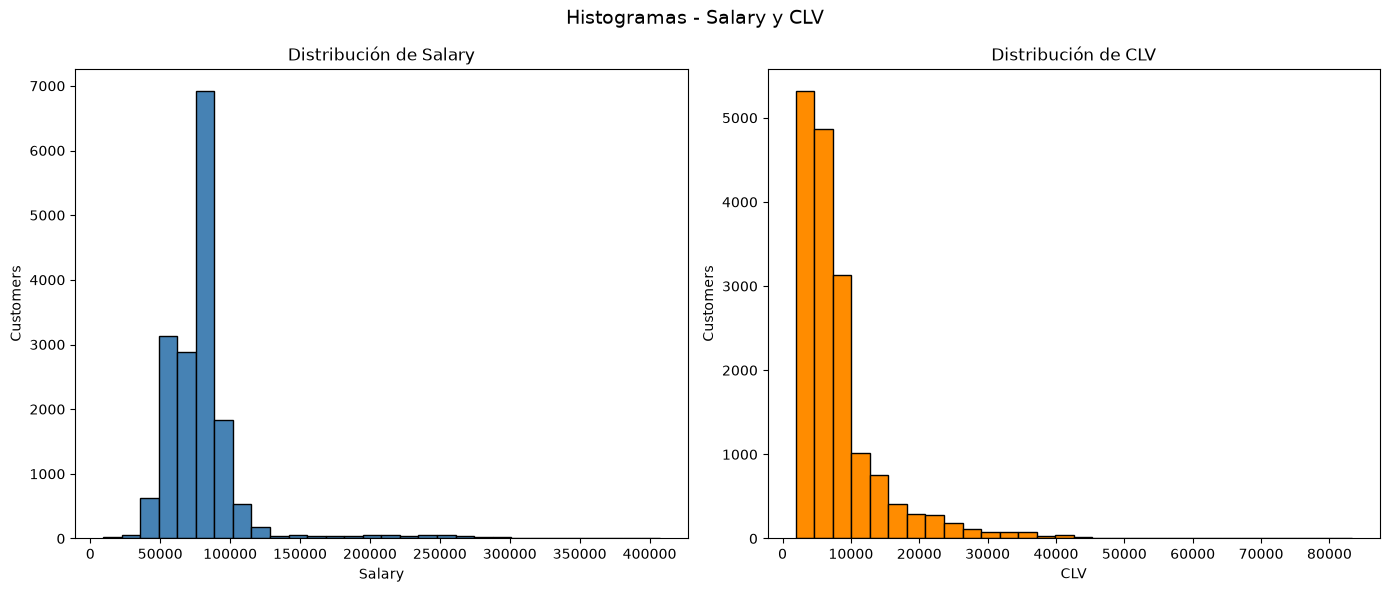

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df_custloyalty['Salary'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Salary')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Customers')

axes[1].hist(df_custloyalty['CLV'].dropna(), bins=30, color='darkorange', edgecolor='black')
axes[1].set_title('Distribución de CLV')
axes[1].set_xlabel('CLV')
axes[1].set_ylabel('Customers')

plt.suptitle('Histogramas - Salary y CLV', fontsize=14)
plt.tight_layout()
plt.show()

***
**Resultado:**

- **Salary**: La media (79.371,36) está ligeramente por encima de la mediana (79.207,98), con un máximo de 407.228. Hay clientes con salarios muy altos que elevan la media.

- **CLV (Customer Lifetime Value)**: mide cuánto dinero aporta cada cliente a la aerolínea a lo largo del tiempo. La media (7.988,90) es superior a la mediana (5.780,18), lo que indica que hay una minoría de clientes muy rentables que elevan el promedio general.
***

Actividad: obtención de outliers o valores atípicos

In [ ]:
# Outliers: con bucle for
for var in estadistica_loyalty:
    q1  = df_custloyalty[var].quantile(0.25)
    q3  = df_custloyalty[var].quantile(0.75)
    IQR = q3 - q1
    
    limite_inferior = q1 - 1.5 * IQR
    limite_superior = q3 + 1.5 * IQR
    
    outliers = df_custloyalty[(df_custloyalty[var] < limite_inferior) | (df_custloyalty[var] > limite_superior)] #selecciono las filas que caen fuera de los límites 
        
    print(f"\n ● {var}")
    print(f"  Límite inferior: {limite_inferior:.2f} | Límite superior: {limite_superior:.2f}")
    print(f"  Outliers: {len(outliers)} ({(len(outliers)/len(df_custloyalty)*100):.2f}%)")


 ● Salary
  Límite inferior: 35337.50 | Límite superior: 111501.50
  Outliers: 866 (5.17%)

 ● CLV
  Límite inferior: -3458.77 | Límite superior: 16380.19
  Outliers: 1485 (8.87%)


Actividad: Visualización de outliers con gráficos BOXPLOT

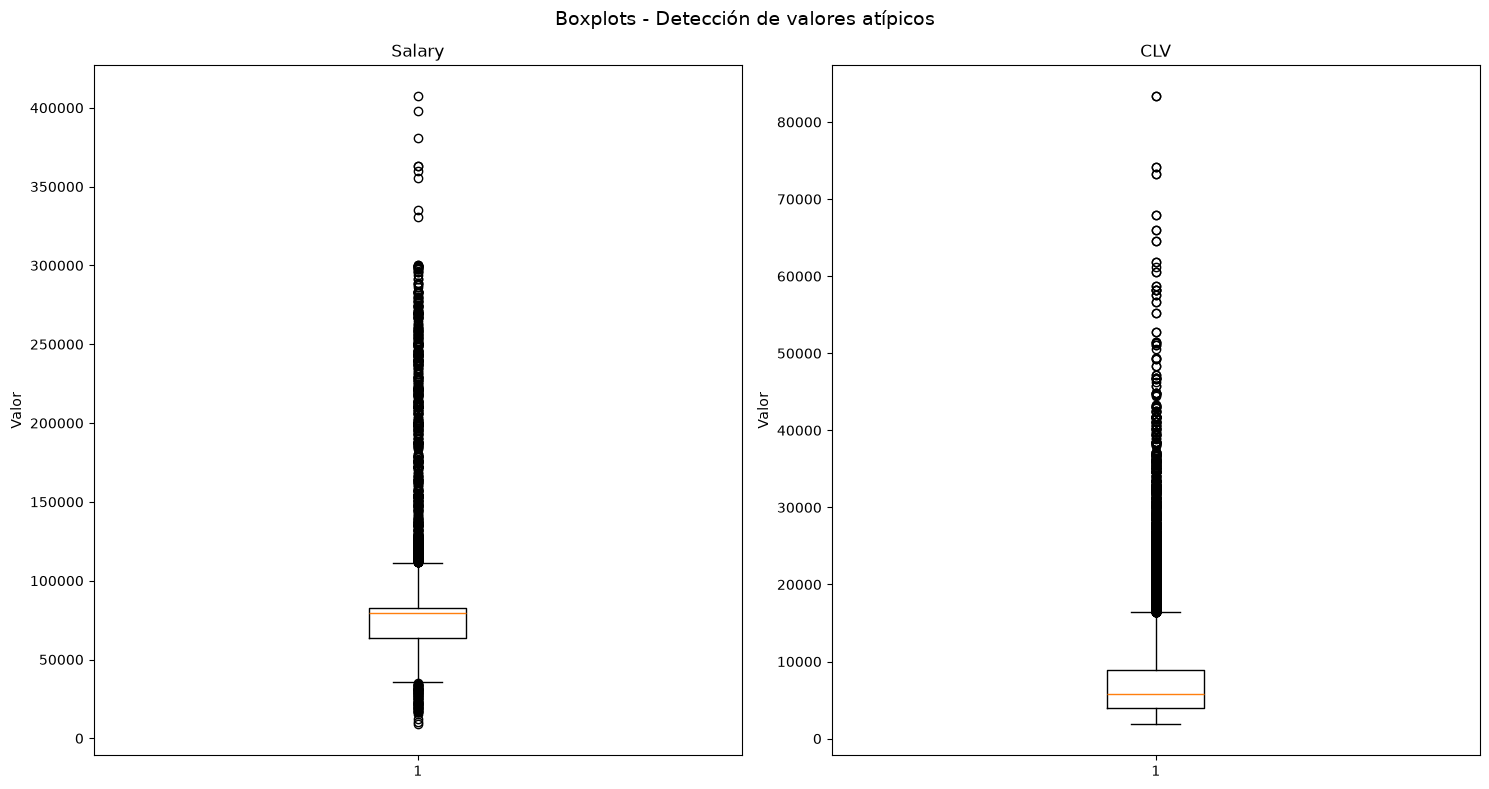

In [72]:
# Creamos un BOXPLOT por cada variable 
fig, axes = plt.subplots(1, 2, figsize=(15, 8)) # figsize controla el tamaño total de la figura en pulgadas
axes = axes.flatten() # # plt.subplots devuelve una matriz 3x3, con .flatten() convertimos la matriz de ejes en una lista para iterar fácilmente

for i, var in enumerate(estadistica_loyalty):
    axes[i].boxplot(df_custloyalty[var].dropna()) # dropna() para ignorar nulos si los hubiera (no hay, pero es buen práctica)
    axes[i].set_title(var)
    axes[i].set_ylabel("Valor")

plt.suptitle("Boxplots - Detección de valores atípicos", fontsize=14)
plt.tight_layout()  #ajusta el espaciado para que no se solapen los subplots
plt.show()

***
**Resultado:**
- **Salary**: un 5,17% de outliers, la mayoría correspondientes a clientes con salarios muy altos (hasta 407.228).

- **CLV**: un 8,8% de outliers, clientes que generan un valor muy alto para la aerolínea.
***

Actividad: Estadísticas básicas de todas la variables numéricas

In [97]:
variables_numericas = ['Flights Booked', 'Flights with Companions', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed', 'Salary', 'CLV']


# Recorremos la variable y calculamos sus estadísticas básicas
# Usamos :.2f para redondear a 2 decimales en la presentación — no afecta a los datos reales
for var in variables_numericas:
    print(f"\n ● {var}")
    print(f"Media: {df_customer[var].mean():.2f}")                       
    print(f"Mediana: {df_customer[var].median():.2f}")                   
    print(f"Moda: {df_customer[var].mode()[0]:.2f}")
    print(f"Varianza: {df_customer[var].var():.2f}")
    print(f"Desviación estándar: {df_customer[var].std():.2f}")
    print(f"Coeficiente de variación: {df_customer[var].std()/df_customer[var].mean():.2f}")
    print(f"Valor mínimo: {df_customer[var].min():.2f}")
    print(f"Valor máximo: {df_customer[var].max():.2f}")
    print(f"Rango: {df_customer[var].max() - df_customer[var].min():.2f}")
        



 ● Flights Booked
Media: 4.13
Mediana: 1.00
Moda: 0.00
Varianza: 27.35
Desviación estándar: 5.23
Coeficiente de variación: 1.27
Valor mínimo: 0.00
Valor máximo: 21.00
Rango: 21.00

 ● Flights with Companions
Media: 1.04
Mediana: 0.00
Moda: 0.00
Varianza: 4.33
Desviación estándar: 2.08
Coeficiente de variación: 2.01
Valor mínimo: 0.00
Valor máximo: 11.00
Rango: 11.00

 ● Total Flights
Media: 5.17
Mediana: 1.00
Moda: 0.00
Varianza: 42.60
Desviación estándar: 6.53
Coeficiente de variación: 1.26
Valor mínimo: 0.00
Valor máximo: 32.00
Rango: 32.00

 ● Distance
Media: 1214.46
Mediana: 525.00
Moda: 0.00
Varianza: 2056638.57
Desviación estándar: 1434.10
Coeficiente de variación: 1.18
Valor mínimo: 0.00
Valor máximo: 6293.00
Rango: 6293.00

 ● Points Accumulated
Media: 124.26
Mediana: 53.00
Moda: 0.00
Varianza: 21519.77
Desviación estándar: 146.70
Coeficiente de variación: 1.18
Valor mínimo: 0.00
Valor máximo: 676.50
Rango: 676.50

 ● Points Redeemed
Media: 30.84
Mediana: 0.00
Moda: 0.00
Varia

- GRÁFICO: HISTOGRAMAS

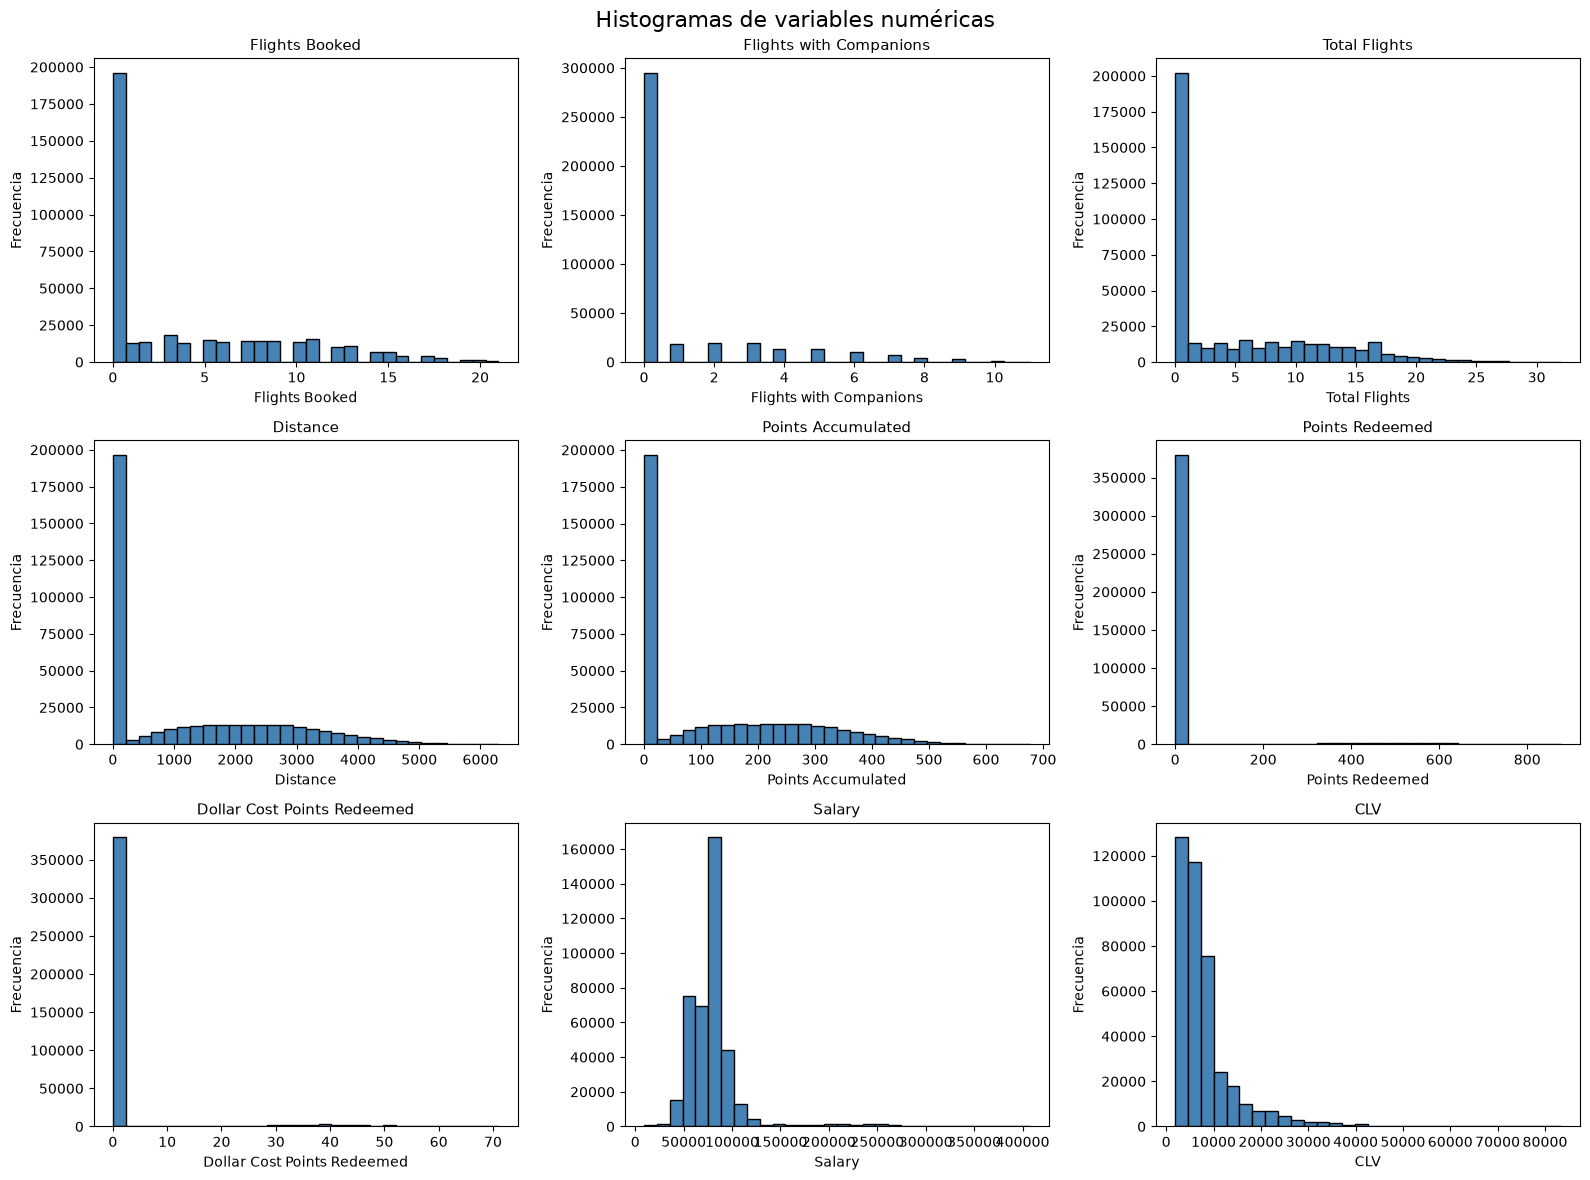

In [21]:
variables = ['Flights Booked', 'Flights with Companions', 'Total Flights', 
             'Distance', 'Points Accumulated', 'Points Redeemed', 
             'Dollar Cost Points Redeemed', 'Salary', 'CLV']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))  # 3x3 porque son 9 variables
axes = axes.flatten()  # convertimos la matriz de ejes en una lista para iterar fácilmente

for i, var in enumerate(variables):
    axes[i].hist(df_customer[var].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Histogramas de variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

***
**Resultado:**

- **Flights Booked, Flights with Companions, Total Flights y Distance**: La mediana es muy baja comparada con la media, y la moda es 0, lo que indica que la mayor parte de los clientes vuela poco. Un grupo reducido de ellos, si que vuela de manera habitual.

- **Points Accumulated, Points Redeemed y Dollar Cost Points Redeemed**: igualmente la mediana es muy baja respecto a la media por lo que la mayoría de clientes acumula pocos puntos y además tampoco los canjea. Hay un bajo aprovechamiento del programa de puntos.

- **Salary y CLV**: Están comentados arriba, que me he basado en el dataset df_custloyalty donde estas dos variables aparecen una vez por cliente y no multiplicadas por el número de meses donde aparece dicho cliente. Aquí los he vuelto a poner en la estadística conjunta porque era más adecuado pora hacer las correlaciones, si bien aparecen multiplicados. La diferencia de las estadísticas es muy pequeña en un dataset y otro (por ej, media y mediana de  Salary en  df_custloyalty: 79.371,36 y 79.207,98 respectivamente y en df_customer: 79.380,84, 79.210,01 respectivamente también).
***

Actividad: obtención de outliers o valores atípicos

In [98]:
#Outliers: igualmente recorremos la variable
for var in variables_numericas:
    q1  = df_customer[var].quantile(0.25)
    q3  = df_customer[var].quantile(0.75)
    IQR = q3 - q1
    
    limite_inferior = q1 - 1.5 * IQR
    limite_superior = q3 + 1.5 * IQR
    
    outliers = df_customer[(df_customer[var] < limite_inferior) | (df_customer[var] > limite_superior)] #selecciono las filas que caen fuera de los límites 
        
    print(f"\n ● {var}")
    print(f"  Límite inferior: {limite_inferior:.2f} | Límite superior: {limite_superior:.2f}")
    print(f"  Outliers: {len(outliers)} ({(len(outliers)/len(df_customer)*100):.2f}%)")


 ● Flights Booked
  Límite inferior: -12.00 | Límite superior: 20.00
  Outliers: 528 (0.13%)

 ● Flights with Companions
  Límite inferior: -1.50 | Límite superior: 2.50
  Outliers: 71560 (17.72%)

 ● Total Flights
  Límite inferior: -15.00 | Límite superior: 25.00
  Outliers: 1984 (0.49%)

 ● Distance
  Límite inferior: -3513.00 | Límite superior: 5855.00
  Outliers: 125 (0.03%)

 ● Points Accumulated
  Límite inferior: -360.00 | Límite superior: 600.00
  Outliers: 112 (0.03%)

 ● Points Redeemed
  Límite inferior: 0.00 | Límite superior: 0.00
  Outliers: 24181 (5.99%)

 ● Dollar Cost Points Redeemed
  Límite inferior: 0.00 | Límite superior: 0.00
  Outliers: 24181 (5.99%)

 ● Salary
  Límite inferior: 35342.50 | Límite superior: 111498.50
  Outliers: 20876 (5.17%)

 ● CLV
  Límite inferior: -3451.23 | Límite superior: 16370.13
  Outliers: 35941 (8.90%)


Actividad: Obtención de outliers con gráficos BOXPLOT

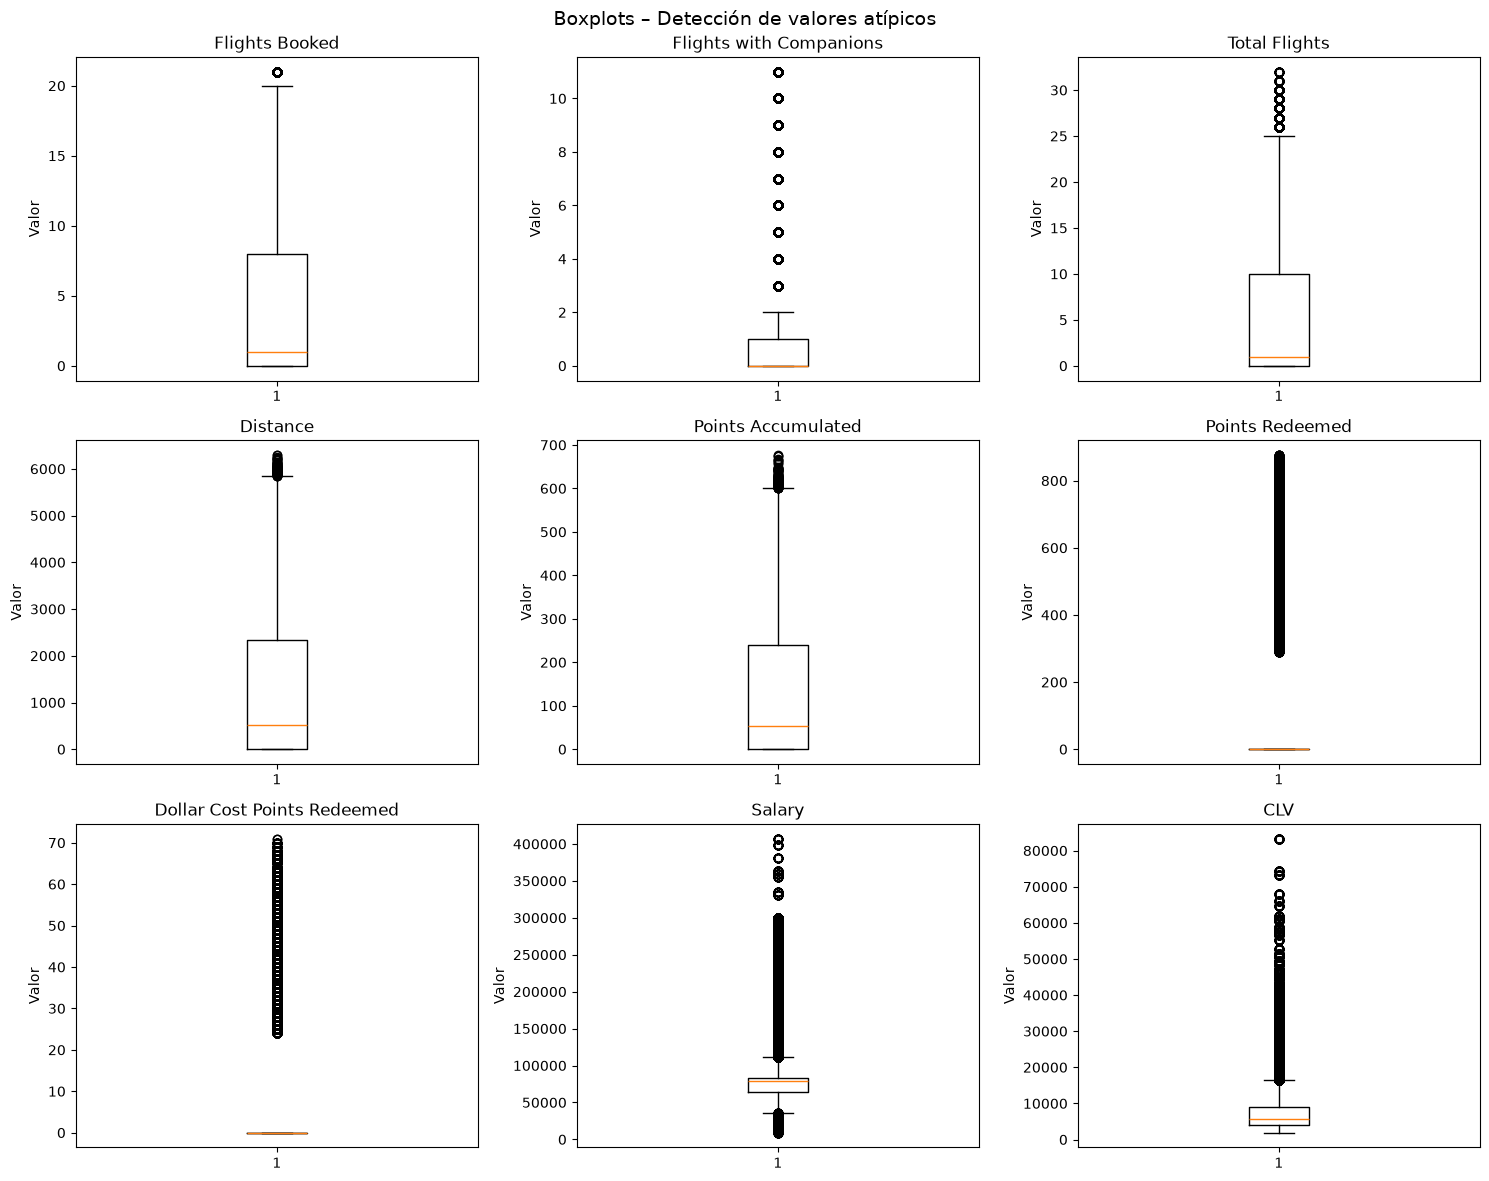

In [ ]:
# Creamos un BOXPLOT por cada variable numérica relevante
# con subplots puedo verlos todos juntos y así poder compararlos
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # figsize controla el tamaño total de la figura en pulgadas
axes = axes.flatten() # # plt.subplots devuelve una matriz 3x3, con .flatten() convertimos la matriz de ejes en una lista para iterar fácilmente

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(df_customer[var].dropna()) # dropna() para ignorar nulos si los hubiera (no hay, pero es buen práctica)
    axes[i].set_title(var)
    axes[i].set_ylabel("Valor")

plt.suptitle("Boxplots - Detección de valores atípicos", fontsize=14)
plt.tight_layout()  #ajusta el espaciado para que no se solapen los subplots
plt.show()

**
**Resultado**

- **Flights Booked, Total Flights y Distance**: hay muy pocos outliers: menos del 5%,  que corresponden a clientes con una actividad de vuelo muy superior a la media. 

- **Flights with Companions**: tiene un porcentaje alto: 17,72 % de outliers porque el límite superior es 2.50. Este porcentaje alto nos dice que la mayoría de clientes viaja solo.

- **Points Redeemed y Dollar Cost Points Redeemed**: el método IQR no es adecuado aquí. Como la mayoría de valores son 0, Q1 y Q3 son ambos 0, lo que supone que todos los valores distintos de 0 sean outliers. Los boxplots confirman visualmente que sí hay valores extremos, pero el porcentaje del IQR no es interpretable en este caso.

- **Salary y CLV**: se comentan arriba.

***

Actividad: matriz de correlación de variables numéricas

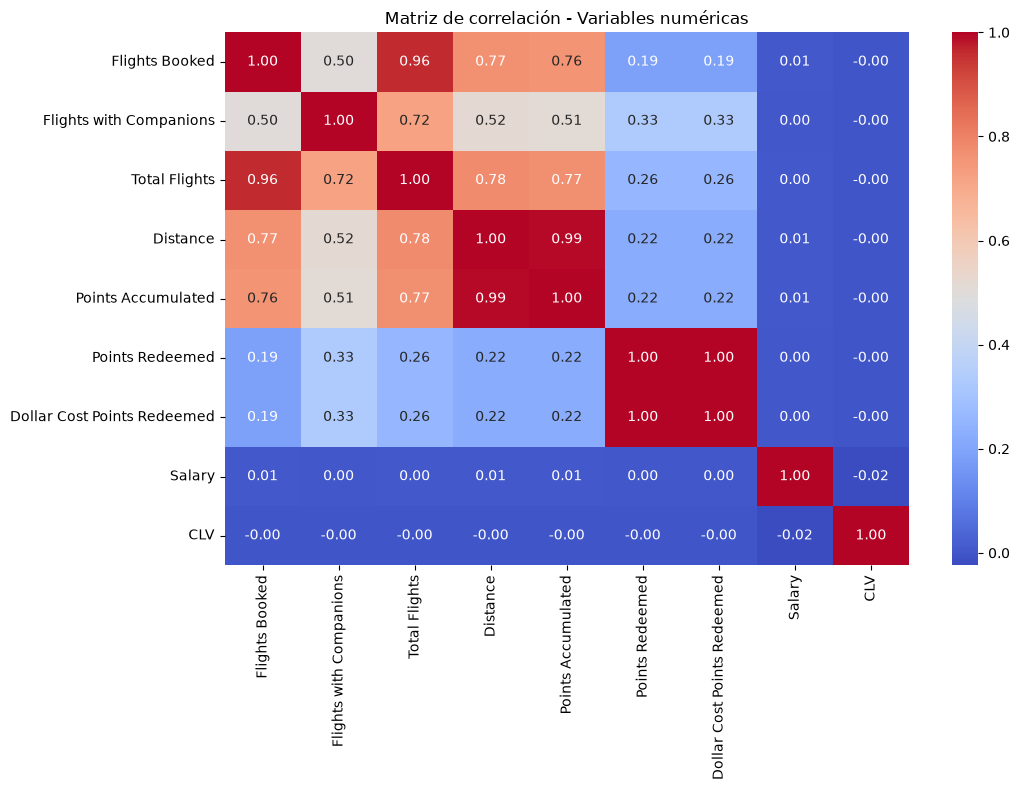

In [100]:
correlacion = df_customer[variables_numericas].corr() # .corr() calcula la matriz de correlación de Pearson entre todas las columnas numéricas seleccionadas

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)            # annot=True → muestra los valores numéricos dentro de cada celda
ax.set_title("Matriz de correlación - Variables numéricas")                        # fmt=".2f" → redondea a 2 decimales
plt.tight_layout()                                                                 # cmap="coolwarm" → azul para correlaciones negativas, rojo para positivas
plt.show()          

***
**Resultado:**

- **Flights Booked, Total Flights, Distance y Points Accumulated:** correlación alta entre ellos. Hay correlación entre los vuelos reservados, los vuelos totales, la distancia y los puntos acumulados, es decir a más vuelos reservados, más se vuela, más distancia se recorre y más puntos se acumulan.

- **Points Redeemed y Dollar Cost Points Redeemed** correlación entre puntos y su equivalente en dólares.

- **Points Redeemed correlaciona más con Flights with Companions que con Flights Booked**, lo que sugiere que los clientes que viajan acompañados tienden a canjear más puntos, posiblemente para obtener beneficios para el grupo.

- **Salary y CLV tienen correlación cercana a 0 con las variables de vuelo**, lo que indica que el salario o el valor del cliente no determinan su actividad de vuelo. Más llamativo aún: Salary y CLV tienen una correlación ligeramente negativa entre sí, lo que sugiere que los clientes con salarios más altos no son los más rentables para la aerolínea.

- **Acumular puntos no implica canjearlos**: Points Accumulated y Points Redeemed tienen una correlación baja, lo que supone que la mayoría de clientes acumula puntos pero no los canjea.
***

## 2. VARIABLES CATEGÓRICAS

Actividad: obtención de frecuencias de las variables categóricas. Realizamos el análisis sobre df_custloyalty para no contar el mismo cliente múltiples veces

In [101]:
# Analizamos la distribución de frecuencias de las variables categóricas relevantes
# .value_counts() cuenta cuántas veces aparece cada categoría
# normalize=True muestra el porcentaje en lugar del conteo absoluto
# Bucle for para recorrer las columnas categóricas

variables_categoricas = ['Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type', 'Province', 'City']  # Lista con las 4 columnas categóricas más relevantes que queremos analizar. 
                                                                              

for varc in variables_categoricas:                                            
    frecuencias = df_custloyalty[varc].value_counts()     
    porcentajes = df_custloyalty[varc].value_counts(normalize=True) * 100   
    
    resumen = pd.DataFrame({'Conteo': frecuencias, 'Porcentaje (%)': porcentajes.round(2)})
    print(f'\n=== {varc} ===')     
    print(resumen)                


=== Gender ===
        Conteo  Porcentaje (%)
Gender                        
Female    8410           50.25
Male      8327           49.75

=== Education ===
                      Conteo  Porcentaje (%)
Education                                   
Bachelor               10475           62.59
College                 4238           25.32
High School or Below     782            4.67
Doctor                   734            4.39
Master                   508            3.04

=== Marital Status ===
                Conteo  Porcentaje (%)
Marital Status                        
Married           9735           58.16
Single            4484           26.79
Divorced          2518           15.04

=== Loyalty Card ===
              Conteo  Porcentaje (%)
Loyalty Card                        
Star            7637           45.63
Nova            5671           33.88
Aurora          3429           20.49

=== Enrollment Type ===
                 Conteo  Porcentaje (%)
Enrollment Type                    

Actividad: visualización de variables categóricas

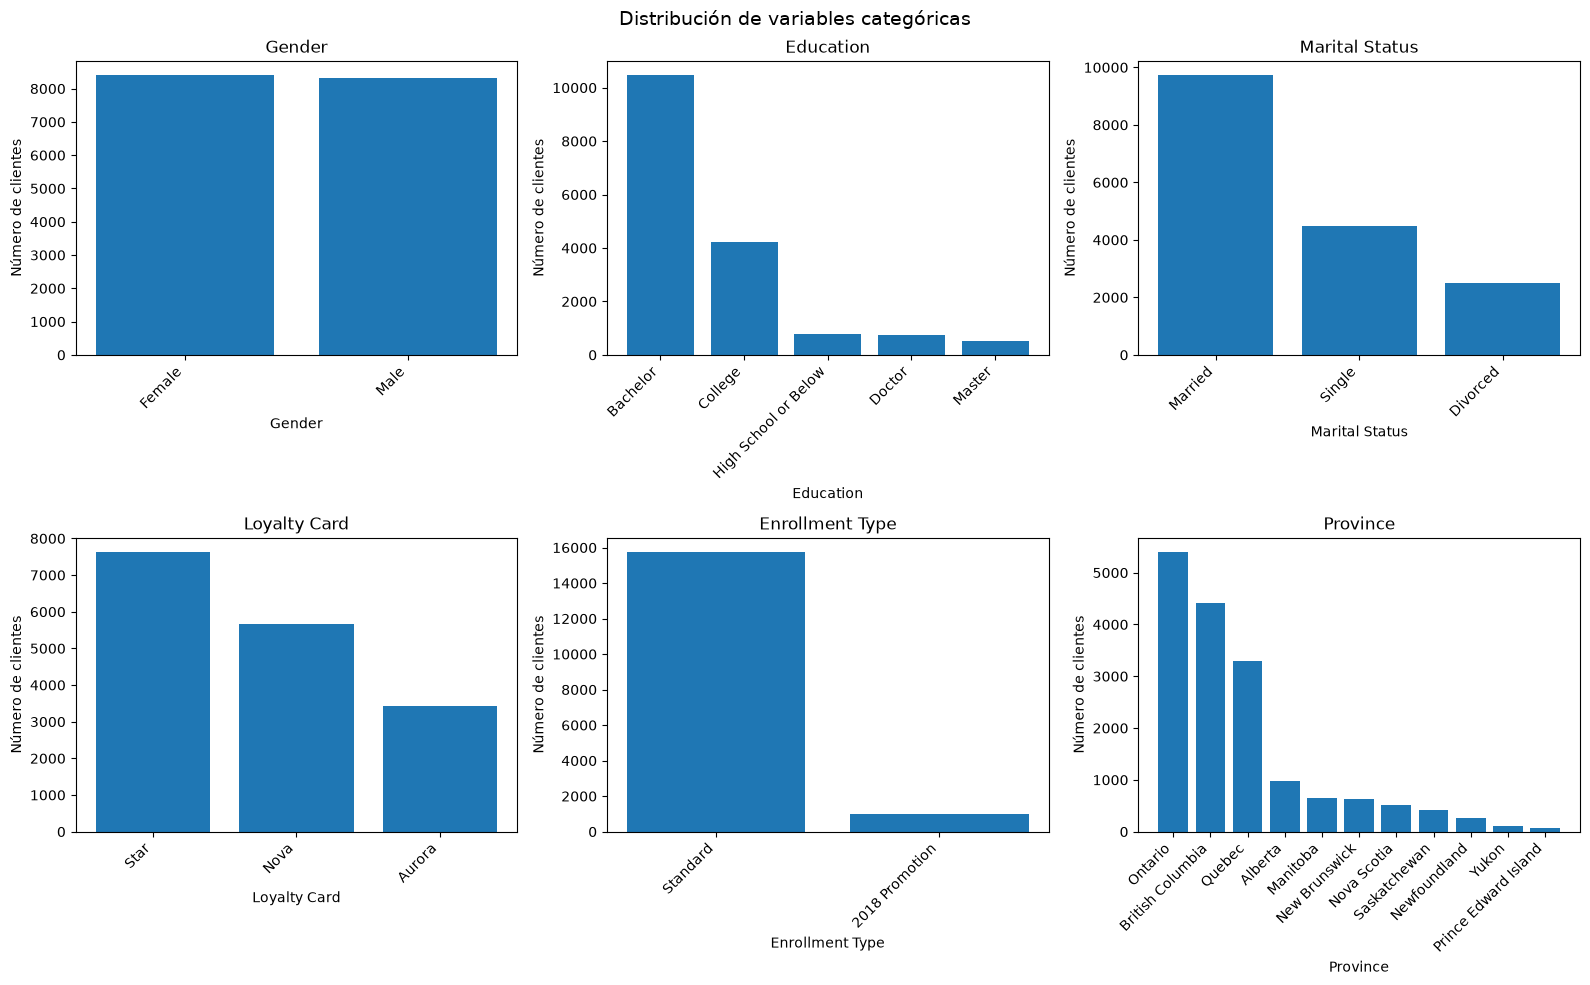

In [102]:
variables_categoricas_graficos = ['Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type', 'Province']

# Visualizamos la distribución de cada variable categórica con un countplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten() # convertimos la matriz de ejes en una lista para iterar fácilmente

for i, varc in enumerate(variables_categoricas_graficos):
    frecuencias = df_custloyalty[varc].value_counts()                
    axes[i].bar(frecuencias.index, frecuencias.values)  
    axes[i].set_title(varc)
    axes[i].set_xlabel(varc)
    axes[i].set_ylabel("Número de clientes")
    axes[i].tick_params(axis='x', rotation=45)           
    plt.setp(axes[i].get_xticklabels(), ha='right')      

plt.suptitle("Distribución de variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

***
**Resultado:**

- **Gender**: distribución similar entre mujeres y hombres.

- **Education**: la gran mayoría de clientes tiene un nivel medio-alto. Bachelor: grado universitario (62.59%) y College: que equivaldría en España a un ciclo formativo superior de FP o una diplomatura técnica (25.32%). Los niveles de Máster, Doctor y estudios básicos son minoritarios.

- **Marital Status**: más de la mitad de los cliente están casados (58.16%), seguidos de solteros (26.79%) y divorciados (15.04%).

- **Loyalty Card**: la tarjeta Star es la que tienen más clientes (45.63%), seguida de Nova (33.88%) y Aurora (20.49%). 

- **Enrollment Type**: Casi todos los clientes (94.23%) se inscribieron de modo estándar. La promoción de 2018 captó muy pocas personas (5.80%).

- **Province**: Los clientes mayoritariamente provienen de  Ontario (32.29%), British Columbia (26.34%) y Quebec (19.72%) que son las provincias más pobladas de Canadá.

- Se descarta City de los gráficos porque los clientes están muy repartidos. Sólo señalar que las capitales de las provincias más pobladas: Ontario, British Columbia y Quebec, que son Toronto, Vancouver y Montreal, respectivamente, concentran más de la mitad de los clientes. Tampoco hemos puesto en la variables categóricas el país porque son todos de Canadá, ni el código postal porque hay muchos y no aportan nada
***

# FASE 3. VISUALIZACION

## ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

In [ ]:
vuelos_por_mes = df.groupby("Month")["Flights Booked"].mean().round(2)  #primero agrupo por mes y calculo la media de los vuelos reservados.

plt.figure(figsize=(10, 5))
sns.lineplot(x=vuelos_por_mes.index, y=vuelos_por_mes.values)
plt.title("Media de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Media de vuelos reservados")
plt.xticks(range(1, 13)) # forzamos que aparezcan todos los meses del 1 al 12
plt.show()

- GRÁFICO: BARPLOT

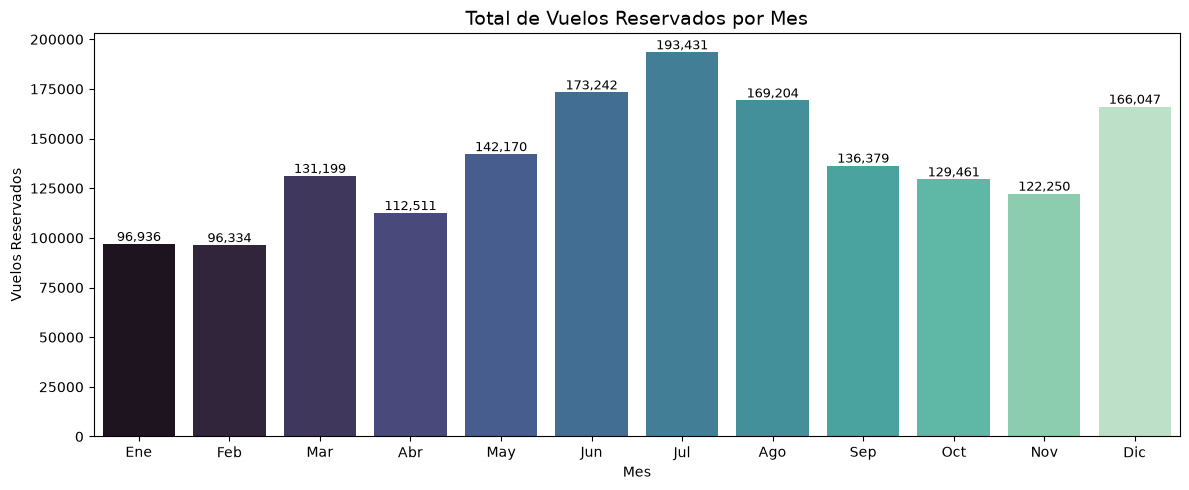

In [ ]:
# Agrupamos los datos por mes y sumamos el total de vuelos reservados en cada mes
# Esto nos da la demanda total de reservas a lo largo del año

vuelos_mes = df_customer.groupby('Month')['Flights Booked'].sum().reset_index()

# Asignamos nombres a los meses para que la gráfica sea más legible
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
vuelos_mes['Mes'] = nombres_meses

# Gráfica de barras: ideal para comparar cantidades entre categorías discretas (meses)
plt.figure(figsize=(12, 5))                                 # más ancha que alta para que los 12 meses quepan bien
ax = sns.barplot(                                           # guardamos la gráfica en una variable para poder añadirle las etiquetas después
    data=vuelos_mes,
    x='Mes',                                                #  eje horizontal = meses
    y='Flights Booked',                                     #  eje vertical = total de vuelos
    palette='mako'    
)

# Añadimos etiquetas encima de cada barra con el valor exacto
for p in ax.patches:                                       # lista de todas las barras de la gráfica
    ax.annotate(f'{int(p.get_height()):,}',         # convierte a entero (sin decimales)  # altura de cada barra = valor numérico # formato con coma de miles
                (p.get_x() + p.get_width() / 2., p.get_height()),  #  posición horizontal = centro de la barra
                ha='center', va='bottom', fontsize=9)      #  alineación horizontal centrada  # alineación vertical desde abajo de la etiqueta


plt.title('Total de Vuelos Reservados por Mes', fontsize=14) #  título de la gráfica
plt.xlabel('Mes')                                            #  etiqueta del eje
plt.ylabel('Vuelos Reservados')                              #  etiqueta del eje
plt.tight_layout()                                           #  ajusta márgenes automáticamente
plt.show()                                                   # muestra la gráfica

***
**Resultado:**

Los meses con mayor número de vuelos reservados son los de verano (junio, julio y agosto), con julio como el pico más alto. Coinciden con las vacaciones de verano.

Se observan también picos en marzo y en diciembre, que son los otros períodos vacacionales.
***

## ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

- GRÁFICO: SCATTERPLOT CON REPGPLOT

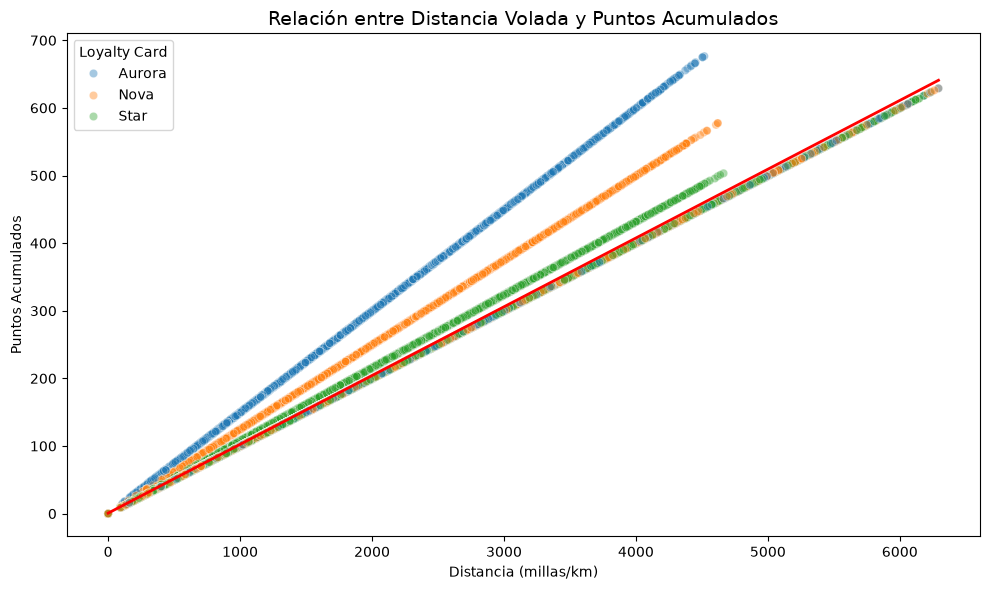

In [ ]:

# Scatter plot (diagrama de dispersión): ideal para ver relaciones entre dos variables numéricas
plt.figure(figsize=(10, 6)) # Figura más alta que el default (10×5) → necesitamos más altura porque los puntos se dispersan verticalmente.
sns.scatterplot(
    data=df_customer,
    x='Distance',           # eje horizontal = distancia
    y='Points Accumulated', #  eje vertical = puntos
    hue='Loyalty Card',     # loyalty card
    alpha=0.4,              # transparencia del 40% para ver la densidad donde se solapan puntos,se ve más oscura,dónde se concentran los datos
    color='steelblue'       # color azul acero
)

# Añadimos la línea de regresión para ver la tendencia
# regplot calcula y dibuja la recta de mejor ajuste automáticamente

sns.regplot(                      
    data=df_customer,
    x='Distance',
    y='Points Accumulated',
    scatter=False,                            # no dibujamos los puntos otra vez (ya los tenemos), solo la línea
    color='red',  
    line_kws={'linewidth': 2}                 #  grosor de la línea = 2
)

# ¿Por qué dos funciones (scatterplot + regplot) en lugar de una?
# Porque regplot solo acepta un color para todo. Con dos funciones podemos tener puntos azules y línea roja.



plt.title('Relación entre Distancia Volada y Puntos Acumulados', fontsize=14)
plt.xlabel('Distancia (millas/km)')
plt.ylabel('Puntos Acumulados')
plt.tight_layout()
plt.show()

***
**Resultado:**

La correlación entre distancia y puntos acumulados es casi del 100%, lo que confirma que los puntos se calculan directamente en base a la distancia recorrida.

La otras tres líneas paralelas, corresponden cada una a un tipo de tarjeta de lealtad. 
***

## ¿Cuál es la distribución de los clientes por provincia o estado?

- GRÁFICO: BARPLOT (usamos df_loyalty para no contar al cliente varias veces)

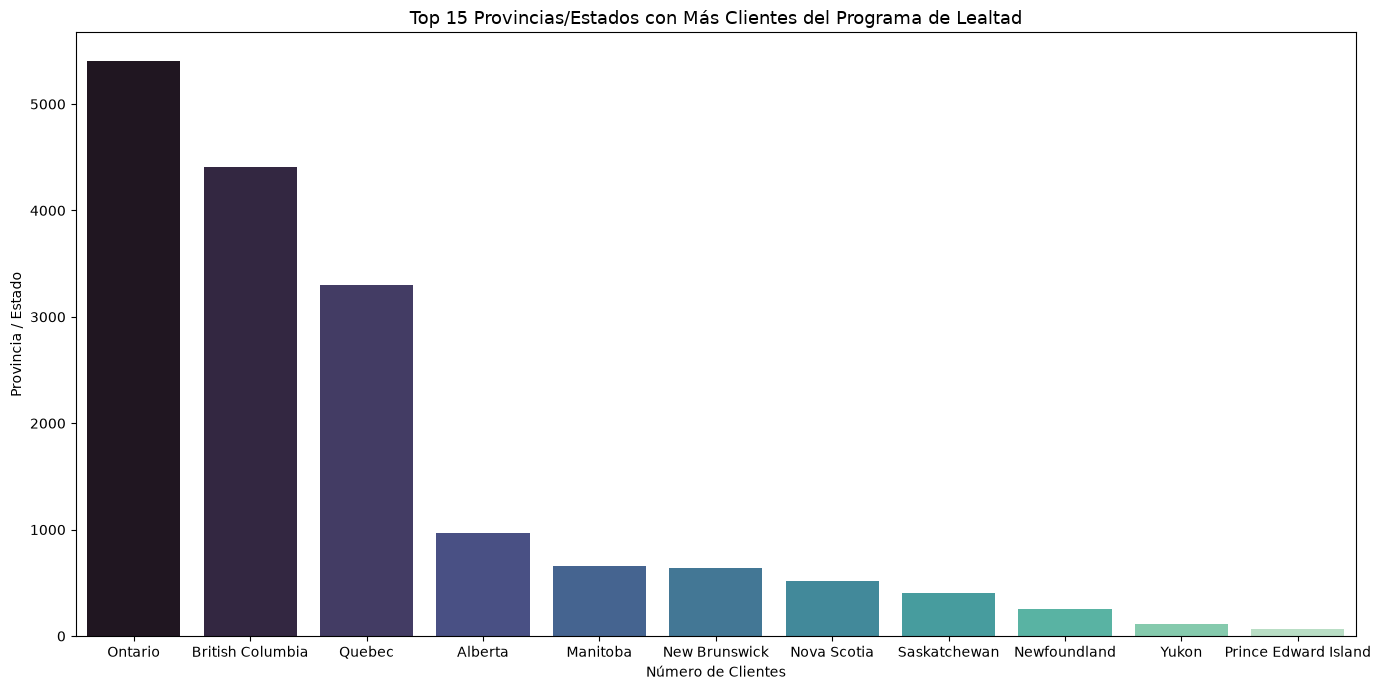

In [ ]:
# Contamos cuántos clientes únicos hay por provincia

clientes_provincia = (
    df_custloyalty['Province']              # columna de provincias del loyalty (no el unido, para no repetir clientes)
    .value_counts()                     # cuenta cuántos clientes hay en cada provincia, ordenado de mayor a menor
    .head(15)                           # mostramos solo las 15 primeras para que el gráfico sea legible
    .reset_index()                      # convierte el resultado en DataFrame con dos columnas
)
clientes_provincia.columns = ['Province', 'Clientes'] # Renombramos las columnas manualmente porque después del reset_index()los nombres automáticos no son claros.


plt.figure(figsize=(14, 7))          
sns.barplot(
    data=clientes_provincia,
    x='Province',                    # la cantidad va en el eje horizontal
    y='Clientes',                    # la categoría va en el eje vertical
    palette='mako'                # paleta de colores 
)

plt.title('Top 15 Provincias/Estados con Más Clientes del Programa de Lealtad', fontsize=13)
plt.xlabel('Número de Clientes')
plt.ylabel('Provincia / Estado')
plt.tight_layout()
plt.show()

***
**Resultado:**
- Los clientes mayoritariamente provienen de  Ontario (32.29%), British Columbia (26.34%) y Quebec (19.72%) que son las provincias más pobladas de Canadá. Luego, el gráfico representa escalonadamente el resto de provincias de procedencia

***

## ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

- GRÁFICO: BARPLOT (usamos df_custloyalty para evitar duplicar clientes)

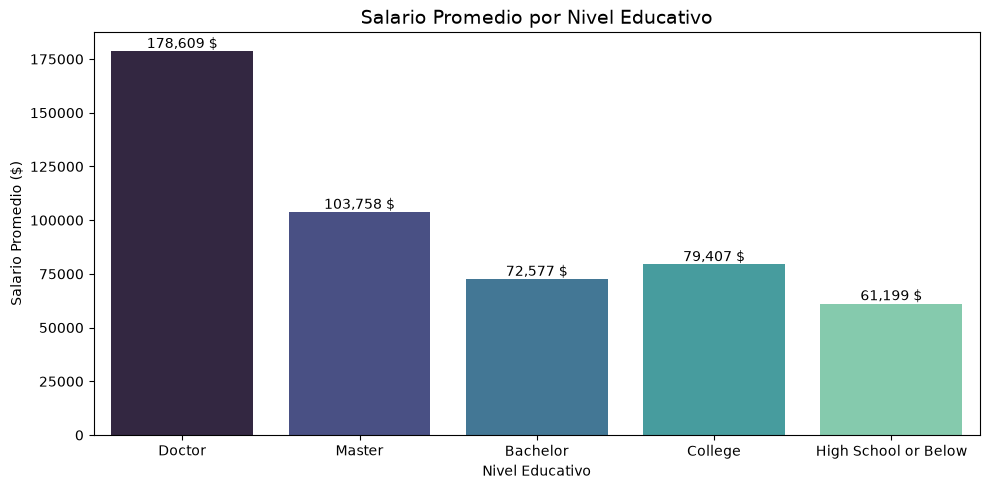

In [ ]:
salario_educacion = (
    df_custloyalty.groupby('Education')['Salary']                  # agrupa por nivel educativo
    .mean()                                                       # calcula el salario medio de cada grupo
    .sort_values(ascending=False)                                 # ordena de mayor a menor salario
    .reset_index()                                                # convierte a DataFrame normal
)
salario_educacion.columns = ['Education', 'Salario Promedio']  # Renombramos las columnas para que sean más descriptivas.


# Definimos un orden lógico de educación de menor a mayor
orden_educacion = ['Doctor', 'Master', 'Bachelor', 'College', 'High School or Below']
# Lista con el orden lógico de menor a mayor nivel educativo. Sin esto las barras saldrían en el orden del sort_values (por salario) en lugar
#  del orden educativo natural.


# Gráfica de barras con orden definido
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=salario_educacion,
    x='Education',
    y='Salario Promedio',
    order=orden_educacion,               #  fuerza el orden de las barras independientemente de cómo estén en el DataFrame
    palette='mako'                     #  paleta amarillo-naranja-rojo (de menor a mayor nivel educativo va oscureciendo)
)

# Añadimos etiquetas con el valor del salario en cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} $',                       # valor de la barra con coma de miles y sin decimales
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Salario Promedio por Nivel Educativo', fontsize=14)
plt.xlabel('Nivel Educativo')
plt.ylabel('Salario Promedio ($)')
plt.tight_layout()
plt.show()

***
**Resultado:**

Cuanto más alto es el nivel educativo, mayor salario promedio con la excepción de los College que tienen el salario ligeramente más alto que los Bachelor. Esto se explica porque ambos son niveles educativos muy similares y además los College pertenecen a profesiones técnicas que están bien pagadas.

Nota: Comparando con España, Bachelor es grado universitario y College, un ciclo formativo superior de FP normalmente técnico o una diplomatura también técnica.

Cabe recordar que los valores de College son todos imputados con un algoritmo, ya que no existían datos reales de salario para ese grupo. 
***

## ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

- GRÁFICO: PIE CHART (usamos loyalty para contar clientes únicos)

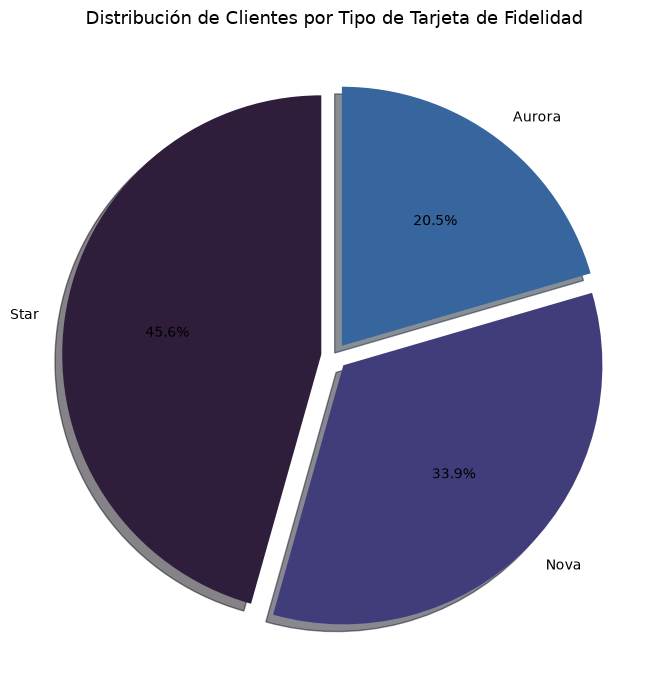

In [ ]:
# Contamos cuántos clientes tienen cada tipo de tarjeta
tarjetas = df_custloyalty['Loyalty Card'].value_counts()  
                                                      # cuenta cuántos clientes tienen cada tarjeta → devuelve Serie de mayor a menor:(7637, 5671, 3429)

# Gráfico de tarta (pie chart): ideal para mostrar proporciones del total
plt.figure(figsize=(7, 7))        #  el pie chart queda mejor en formato cuadrado que rectangular.
plt.pie(
    tarjetas.values,
    labels=tarjetas.index,  # los nombres (Star, Nova, Aurora) → etiquetas de cada sector
    autopct='%1.1f%%',     # muestra el porcentaje con 1 decimal
    startangle=90,          # empieza desde arriba  # desde las 12 en punto (arriba). Sin esto empieza desde las 3 en punto (derecha) → menos natural visualmente.
    colors=sns.color_palette('mako'),   # Usa la paleta de colores Set2 de seaborn → colores pastel suaves y diferenciables.
    explode=[0.05] * len(tarjetas),  # separa levemente cada sector para mejor visualización  # 5% de separación # crea automáticamente [0.05, 0.05, 0.05]
    shadow=True                        # Añade sombra debajo del gráfico para dar efecto de profundidad visual.
)

plt.title('Distribución de Clientes por Tipo de Tarjeta de Fidelidad', fontsize=13)
plt.tight_layout()
plt.show()

***
**Resultado:**

La tarjeta Star es la que tienen más clientes, con casi la mitad del total (45.60%), seguida de Nova (33.90%) y Aurora (20.50%). La distribución es escalonada.

***

## ¿Cómo se distribuyen los clientes según su estado civil y género?

- GRÁFICO: COUNTPLOT

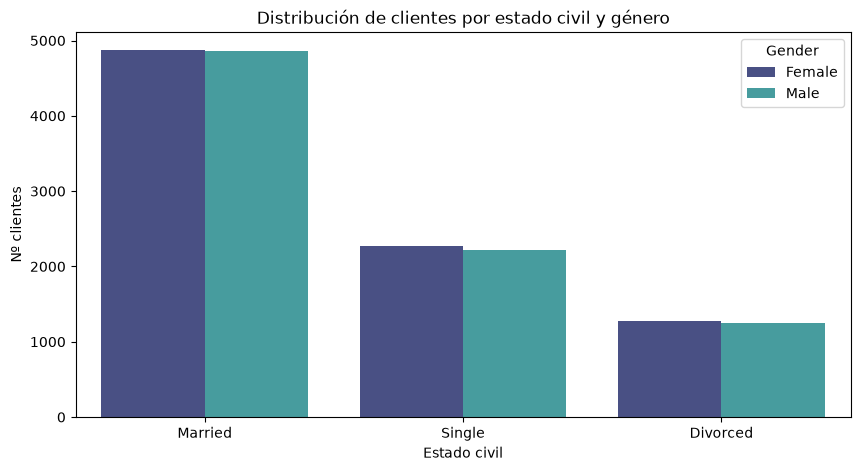

In [115]:
orden_marital = df_custloyalty['Marital Status'].value_counts().index # Ordenamos el estado civil de mayor a menor número de clientes

plt.figure(figsize=(10, 5))
sns.countplot(x='Marital Status', data=df_custloyalty, order=orden_marital, hue='Gender', palette='mako')   # hue="Gender" → divide cada barra en dos: Female y Male
plt.xlabel("Estado civil")
plt.ylabel("Nº clientes")
plt.title("Distribución de clientes por estado civil y género")
plt.show()

***
**Resultados:**

El gráfico muestra que la mayoría de clientes está casado, duplicando al siguiente grupo que son los solteros y mucha distancia de los divorciados. 

En cuanto al género, la distribución es similar en los tres grupos y hombres y mujeres están igualados. Esto confirma lo que ya vimos en la Fase 2, que el género no es una variable relevante para explicar el comportamiento de los clientes en este programa de lealtad.
***

# FASE 4: EVALUACIÓN DE DIFERENCIAS EN RESERVAS DE VUELOS POR NIVEL EDUCATIVO

Actividad: Utilizando un conjunto de datos que hemos compartido, se busca evaluar si existen diferencias
significativas en el número de vuelos reservados según el nivel educativo de los clientes. Para ello, los
pasos que deberás seguir son:
- Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes:
'Flights Booked' y 'Education'.
- Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas
básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada
grupo.

In [112]:
# Creación data Frame con solo esas dos columnas
df_vuelos_educacion = df_customer[['Flights Booked', 'Education']]
df_vuelos_educacion.head()

,Flights Booked,Education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor


In [113]:
estadisticas_vuelos = df_vuelos_educacion.groupby('Education')['Flights Booked'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
print(estadisticas_vuelos)

                      mean  median  std  min  max   count
Education                                                
Bachelor              4.11    1.00 5.22    0   21  252567
College               4.17    1.00 5.25    0   21  102260
Doctor                4.18    1.00 5.26    0   21   17731
High School or Below  4.18    1.00 5.24    0   21   18915
Master                4.20    1.00 5.21    0   21   12287


In [114]:
# Comprobación de que Bachelor y College son los grupos más numerosos
df_custloyalty['Education'].value_counts()

Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

- GRÁFICO: BOXPLOT

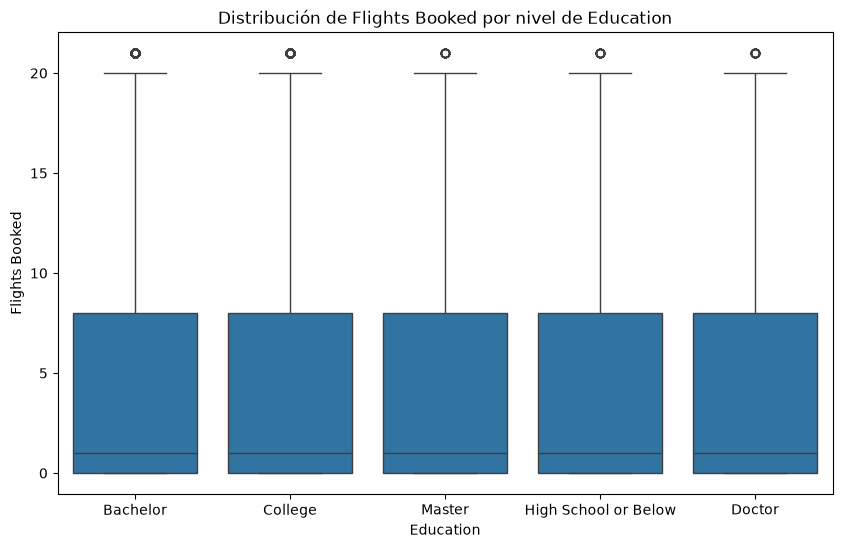

In [ ]:
# BOXPLOT
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_vuelos_educacion, x='Education', y='Flights Booked')
plt.title('Distribución de Flights Booked por nivel de Education')
plt.xlabel('Education')
plt.ylabel('Flights Booked')
plt.show()

Resultado: 
- Los números son muy similares entre grupos por lo que el nivel educativo no influye en la cantidad de vuelos reservados.
- Count es más elevado en Bachelor y College porque son los dos grupos más numerosos no porque vuelen más